# Final Results — the Test Year

The last notebook of the benchmark. Every approach compared in notebook 11 is **retrained on
all the data available before the test year** (train + validation) with the configuration its
own notebook selected. Each one forecasts the 12 months after that data and is scored **once**
on the test set (`test.parquet`), the year that no earlier notebook has read.

| Approach | Selected in | Retrained here as |
|---|---|---|
| SARIMAX | notebook 5 | the same orders, data selection and target processing, refitted up to the last validation month |
| Local ML | notebook 7 | the same family, target processing, window, COVID rows, strategy, features and tuned tree parameters |
| Global ML | notebook 8 | the same, on the panel of notebook 8; the total is the bottom-up sum of the series forecasts |
| TimesFM | notebook 9 | zero-shot: nothing is trained; the context now ends at the last validation month |
| Best ensemble (all), Best stacking (all) | notebook 10, as in notebook 11 | the same method over the four retrained approaches, with weights fitted on the validation forecasts |
| Best ensemble (best 2), Best stacking (best 2) | notebook 10, as in notebook 11 | the same, over the two approaches of notebook 10's best-2 pool |
| Seasonal naive, Naive | reference rows (grey) | same month last year / last month repeated |

**Steps.**

1. Read the selected configurations from MLflow. Nothing is chosen in this notebook.
2. Retrain each approach. It must first **reproduce its logged validation forecasts** at the four
   validation origins; only then is it refitted at the test origin.
3. Fit the combination weights on the validation forecasts only.
4. **Freeze** every forecast, then open the test set and score them.
5. Compare the test scores with the validation scores and log the results to MLflow.

### Leakage Guards

| Risk | Guard in this notebook |
|---|---|
| The test year shapes a model | The test file is read in section 5, after every forecast is built and fingerprinted; the fingerprint is checked again after scoring |
| Re-selection on the test year | Every configuration, combination method and pool is read from MLflow as selected on the validation origins; no choice depends on the test scores |
| Test values inside the refit | Every model, target transformation, early-stopping holdout and penalty search sees only the history up to the last validation month; the forecast months are the 12 calendar months after it |
| Stacking and ensemble weights | Fitted on the **validation forecasts** of notebook 10 (four origins, 48 months, each forecast made without the months it predicts). Never on the test year, and never on the retrained models' in-sample fit, which would reward the model that overfits most |
| Weights learned twice | The weights are refitted on the 48 validation months and must equal the final weights logged by notebook 10 |
| Scale of the metric | The seasonal MASE scale is the in-sample MAE of the seasonal naive on the history up to the last validation month |
| Global ML panel | The series of the panel are chosen by notebook 8's rules on the training rows, as when the configuration was selected |
| TimesFM pretraining | The public corpus of a foundation model is out of this project's control; see *Caveats* |

## Setup

In [1]:
import hashlib
import json
import os
import re
import sys
import tempfile
import time
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import Markdown, display
from scipy.stats import spearmanr
from sklearn.linear_model import HuberRegressor, LassoCV, LinearRegression, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')
if ROOT_PATH not in sys.path:
    sys.path.insert(0, ROOT_PATH)

# the pipelines of notebooks 5, 7, 8 and 9, refittable at any origin
from benchmark_pipelines import (  # noqa: E402
    global_ml,
    local_ml,
    sarimax,
    timesfm_zero_shot,
)
from benchmark_pipelines.common import (  # noqa: E402
    FREQ,
    SEASONAL_PERIOD,
    TARGET,
    forecast_dates,
    seasonal_mase_scale,
)

# growth regimes of notebook 11 (growth of a year over the previous 12 months)
FLAT_GROWTH = 0.05
RAPID_GROWTH = 0.30
REPRODUCTION_RTOL = 1e-6  # max relative difference to the logged validation forecasts
WEIGHTS_ATOL = 1e-4  # notebook 10 logs its final weights rounded to 4 decimals

APPROACH_COLORS = {
    'SARIMAX': '#1f77b4',
    'Local ML': '#ff7f0e',
    'Global ML': '#2ca02c',
    'TimesFM': '#d62728',
    'Best ensemble (all)': '#9467bd',
    'Best stacking (all)': '#8c564b',
    'Best ensemble (best 2)': '#e377c2',
    'Best stacking (best 2)': '#bcbd22',
    'Seasonal naive': '#4d4d4d',
    'Naive': '#a6a6a6',
}
MEMBERS = ['SARIMAX', 'Local ML', 'Global ML', 'TimesFM']
BASELINES = ['Seasonal naive', 'Naive']

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
client = mlflow.MlflowClient()

## 1. The Data Available Before the Test Year

Only `train.parquet` and `val.parquet` are read here, aggregated to the monthly total exactly as
in notebooks 5–9. Their last month is the **test origin**: every model is refitted on the history
up to it, and the forecast months are the 12 calendar months after it. The test file is not
opened until section 5.

In [2]:
PRE_TEST_FILES = ['train.parquet', 'val.parquet']


def load_rows(file_name):
    return pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))


def monthly_total(rows):
    return rows.set_index('date')[TARGET].resample(FREQ).sum()


train_rows, val_rows = (load_rows(file_name) for file_name in PRE_TEST_FILES)
history = pd.concat([monthly_total(train_rows), monthly_total(val_rows)])
TRAIN_END = train_rows['date'].max()
TEST_ORIGIN = history.index[-1]  # the last validation month
FORECAST_DATES = forecast_dates(TEST_ORIGIN)
HISTORY_FINGERPRINT = hashlib.sha256(history.to_numpy().tobytes()).hexdigest()

assert history.index.is_unique
assert history.index.is_monotonic_increasing
assert len(pd.date_range(history.index[0], TEST_ORIGIN, freq=FREQ)) == len(history)
print(
    f'History: {history.index[0]:%b %Y} → {TEST_ORIGIN:%b %Y} ({len(history)} months, '
    f'train up to {TRAIN_END:%b %Y})'
)
print(f'Forecast months: {FORECAST_DATES[0]:%b %Y} → {FORECAST_DATES[-1]:%b %Y}')

History: Jan 1989 → Aug 2025 (440 months, train up to Aug 2024)
Forecast months: Sep 2025 → Aug 2026


## 2. The Selected Configurations (read from MLflow)

Nothing is selected in this notebook. For each approach, the selection of its notebook is read
back from MLflow:

- the latest run tagged `role = best_validation_forecasts` names the selected configuration and
  stores its forecasts at the four validation origins;
- the grid run with the same configuration and the same mean seasonal MASE gives its parameters,
  including the Optuna tree parameters of a tuned configuration.

The four combinations follow notebook 11's rule: among the latest run of each notebook 10 method,
the lowest mean seasonal MASE of each kind (ensemble or stacking) and pool (`all` or `best_2`).
Each run lists its members, so the pools are the ones notebook 10 chose on validation.

In [3]:
MEMBER_EXPERIMENTS = {
    'SARIMAX': 'Brazil Tourism Forecasting ARIMA',
    'Local ML': 'Brazil Tourism Forecasting ML',
    'Global ML': 'Brazil Tourism Forecasting ML Global',
    'TimesFM': 'Brazil Tourism Forecasting TimesFM',
}
ENSEMBLE_EXPERIMENT = 'Brazil Tourism Forecasting Ensembles'
GRID_RUNS = "attributes.status = 'FINISHED' and params.eval_split = 'validation'"
SELECTION_METRIC = {'SARIMAX': 'mase_mean'} | dict.fromkeys(MEMBERS[1:], 'MASE_mean')
PIPELINES = {
    'SARIMAX': sarimax,
    'Local ML': local_ml,
    'Global ML': global_ml,
    'TimesFM': timesfm_zero_shot,
}


def experiment_id(name):
    found = mlflow.get_experiment_by_name(name)
    assert found is not None, f'experiment "{name}" not found: run its notebook first'
    return found.experiment_id


def read_validation_forecasts(run):
    path = mlflow.artifacts.download_artifacts(
        run_id=run.info.run_id,
        artifact_path='validation_forecasts.csv',
        dst_path=tempfile.mkdtemp(),
    )
    return pd.read_csv(path, parse_dates=['date'])


def grid_label(approach, params):
    """The configuration label a notebook gives to one of its grid runs."""
    if approach == 'SARIMAX':
        return sarimax.SarimaxConfig.from_params(params).label
    label = PIPELINES[approach].Config.from_params(params).label
    return label + (' | tuned' if params.get('tuned') == 'True' else '')


def select_member(approach):
    """The selected configuration: the latest pointer run and its matching grid run."""
    experiment = experiment_id(MEMBER_EXPERIMENTS[approach])
    pointers = client.search_runs(
        [experiment],
        filter_string="tags.role = 'best_validation_forecasts'",
        order_by=['attributes.start_time DESC'],
        max_results=1,
    )
    assert pointers, f'{approach}: run the last section of its notebook first'
    pointer = pointers[0]
    metric = SELECTION_METRIC[approach]
    grid = client.search_runs(
        [experiment],
        filter_string=GRID_RUNS,
        order_by=[f'metrics.{metric} ASC'],
        max_results=100,
    )
    matches = [
        run
        for run in grid
        if grid_label(approach, run.data.params) == pointer.data.params['configuration']
        and np.isclose(run.data.metrics[metric], pointer.data.metrics['MASE_mean'])
    ]
    assert matches, (
        f'{approach}: no grid run matches {pointer.data.params["configuration"]}'
    )
    grid_run = max(matches, key=lambda run: run.info.start_time)
    return {
        'configuration': pointer.data.params['configuration'],
        'params': grid_run.data.params,
        'validation MASE_mean': pointer.data.metrics['MASE_mean'],
        'validation': read_validation_forecasts(pointer),
    }


members = {approach: select_member(approach) for approach in MEMBERS}

# notebook 10: the latest run of each method, then the best of each kind and pool
ensemble_runs = client.search_runs(
    [experiment_id(ENSEMBLE_EXPERIMENT)],
    filter_string="tags.role = 'ensemble_validation_forecasts'",
    order_by=['attributes.start_time DESC'],
)
assert ensemble_runs, (
    'notebook 10: re-run it so that it stores its validation forecasts'
)
latest_per_method = {}
for run in ensemble_runs:  # newest first
    latest_per_method.setdefault(run.data.params['method'], run)


def pool_of(run):
    return run.data.tags.get('subset') or (
        'best_2' if '(best 2)' in run.data.params['method'] else 'all'
    )


combinations = {}
for kind, pool, approach in [
    ('ensemble', 'all', 'Best ensemble (all)'),
    ('stacking', 'all', 'Best stacking (all)'),
    ('ensemble', 'best_2', 'Best ensemble (best 2)'),
    ('stacking', 'best_2', 'Best stacking (best 2)'),
]:
    candidates = [
        run
        for run in latest_per_method.values()
        if run.data.tags.get('kind') == kind and pool_of(run) == pool
    ]
    assert candidates, f'no notebook 10 run for {approach}'
    best = min(candidates, key=lambda run: run.data.metrics['MASE_mean'])
    method = best.data.params['method']
    combinations[approach] = {
        'configuration': method,
        'method': re.sub(r' \((all|best 2)\)$', '', method),
        'pool': best.data.params['members'].split(', '),
        'params': best.data.params,
        'validation MASE_mean': best.data.metrics['MASE_mean'],
    }
    assert set(combinations[approach]['pool']) <= set(MEMBERS)

pd.DataFrame([
    {
        'approach': approach,
        'configuration': entry['configuration'],
        'members': ', '.join(entry.get('pool', [approach])),
        'validation MASE_mean': entry['validation MASE_mean'],
    }
    for approach, entry in {**members, **combinations}.items()
]).set_index('approach').round(3)

,configuration,members,validation MASE_mean
approach,,,
SARIMAX,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",SARIMAX,0.992
Local ML,XGBoost | seasonal_log_diff | last_4y | keep |...,Local ML,0.982
Global ML,XGBoost | seasonal_log_diff | last_6y | keep |...,Global ML,1.101
TimesFM,all | remove | none | calendar | symmetric,TimesFM,1.312
Best ensemble (all),mean (all),"SARIMAX, Local ML, Global ML, TimesFM",0.949
Best stacking (all),lasso stacking (all),"SARIMAX, Local ML, Global ML, TimesFM",1.031
Best ensemble (best 2),mean (best 2),"Local ML, SARIMAX",0.932
Best stacking (best 2),huber stacking (best 2),"Local ML, SARIMAX",0.946


## 3. Retraining the Four Approaches

The pipelines live in the package `benchmark_pipelines/` (one module per notebook: `sarimax`,
`local_ml`, `global_ml`, `timesfm_zero_shot`). Each module is a copy of its notebook's code with
the history and the origin passed as arguments. Every function cuts the history at the origin it
receives, so a model refitted at an origin never sees a later month.

**Reproduction check first.** Each approach is refitted at the four validation origins and must
reproduce the forecasts its notebook logged (maximum relative difference below
`REPRODUCTION_RTOL`). This shows that the retrained pipeline is the selected one, with the same
data, features and parameters. Only then is it refitted at the test origin.

What "retrained" means for each approach:

- **SARIMAX, Local ML, Global ML**: fitted again on the history up to the test origin. The training
  windows (`last_Ny`) are counted back from it, as they were from each validation origin. The
  target processing is fitted on that history, and the trees' early stopping holds out its last
  12 months.
- **Global ML**: the panel keeps the series notebook 8 chose from the training rows. Its values run
  up to the test origin.
- **TimesFM**: nothing is trained. The context simply ends at the test origin.

In [4]:
FEATURE_SPEC = local_ml.load_feature_spec(
    os.path.join(DATA_FOLDER_PATH, 'feature_groups.json')
)
panel = global_ml.build_panel(
    pd.concat([train_rows, val_rows], ignore_index=True), rules_end=TRAIN_END
)
timesfm_model = timesfm_zero_shot.load_model(members['TimesFM']['params']['model'])


def tree_params_of(params):
    return json.loads(params['tree_params']) if 'tree_params' in params else None


def make_forecaster(approach, params):
    """origin -> forecast of the total (arrivals) of the selected configuration."""
    if approach == 'SARIMAX':
        config = sarimax.SarimaxConfig.from_params(params)
        return lambda origin: sarimax.forecast(config, history, origin)
    if approach == 'Local ML':
        config = local_ml.Config.from_params(params)
        tree_params = tree_params_of(params)
        return lambda origin: local_ml.forecast(
            config, tree_params, history, origin, FEATURE_SPEC
        )
    if approach == 'Global ML':
        config = global_ml.Config.from_params(params)
        tree_params = tree_params_of(params)
        return lambda origin: global_ml.forecast(
            config, tree_params, panel, origin, FEATURE_SPEC
        )[0]  # the bottom-up total
    config = timesfm_zero_shot.Config.from_params(params)
    return lambda origin: timesfm_zero_shot.forecast(
        timesfm_model, config, history, origin
    )[0]  # the median


def origin_date(label):
    return pd.Timestamp(label) + pd.offsets.MonthEnd(0)


reproduction, member_forecasts, refit_seconds = [], {}, {}
for approach, member in members.items():
    forecaster = make_forecaster(approach, member['params'])
    for label, logged in member['validation'].groupby('origin'):
        produced = forecaster(origin_date(label))
        assert produced.index.equals(pd.DatetimeIndex(logged['date']))
        reproduction.append({
            'approach': approach,
            'origin': label,
            'max relative difference': float(
                np.max(np.abs(produced.to_numpy() / logged['forecast'].to_numpy() - 1))
            ),
        })
    worst = max(
        r['max relative difference'] for r in reproduction if r['approach'] == approach
    )
    assert worst < REPRODUCTION_RTOL, (
        f'{approach} does not reproduce its validation forecasts (max relative '
        f'difference {worst:.2e}): the pipeline differs from its notebook'
    )
    start = time.perf_counter()
    member_forecasts[approach] = forecaster(TEST_ORIGIN)
    refit_seconds[approach] = time.perf_counter() - start

# the 80% interval of TimesFM at the test origin (0.1 and 0.9 quantiles)
_, timesfm_low, timesfm_high = timesfm_zero_shot.forecast(
    timesfm_model,
    timesfm_zero_shot.Config.from_params(members['TimesFM']['params']),
    history,
    TEST_ORIGIN,
)

for approach, forecast in member_forecasts.items():
    assert forecast.index.equals(FORECAST_DATES), approach
    assert forecast.notna().all(), approach
assert hashlib.sha256(history.to_numpy().tobytes()).hexdigest() == HISTORY_FINGERPRINT

display(
    pd
    .DataFrame(reproduction)
    .pivot_table(
        index='approach',
        columns='origin',
        values='max relative difference',
        aggfunc='first',
    )
    .reindex(MEMBERS)
    .map('{:.1e}'.format)
    .rename_axis('max relative difference to the logged validation forecasts')
)
pd.DataFrame({
    'configuration': {a: members[a]['configuration'] for a in MEMBERS},
    'refit at the test origin (s)': refit_seconds,
    'forecast of the test year (sum)': {
        a: f.sum() for a, f in member_forecasts.items()
    },
}).round(1)

origin,2017-08,2018-08,2023-08,2024-08
max relative difference to the logged validation forecasts,,,,
SARIMAX,1.1e-16,1.1e-16,2.2e-16,2.2e-16
Local ML,2.2e-16,2.2e-16,1.1e-16,0.0e+00
Global ML,1.1e-16,0.0e+00,1.1e-16,0.0e+00
TimesFM,0.0e+00,0.0e+00,0.0e+00,0.0e+00


,configuration,refit at the test origin (s),forecast of the test year (sum)
SARIMAX,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.2,11992456.3
Local ML,XGBoost | seasonal_log_diff | last_4y | keep |...,0.8,13814624.9
Global ML,XGBoost | seasonal_log_diff | last_6y | keep |...,1.8,11683426.7
TimesFM,all | remove | none | calendar | symmetric,0.5,9375575.8


## 4. The Combinations: Weights From the Validation Forecasts Only

A combination needs **out-of-sample** forecasts of its members to learn from. The only ones the
project has are the validation forecasts: at each of the four validation origins, every member
forecast 12 months it had not seen. That makes 48 months, the data notebook 10 used.

- **Mean, median**: nothing to learn; applied directly to the retrained members' test forecasts.
- **Inverse-MASE mean**: weights ∝ 1 / the member's mean seasonal MASE over the four validation
  origins.
- **Stacking (Huber, linear, Ridge, Lasso)**: the regression of notebook 10 (no intercept,
  non-negative weights except Huber, penalty by leave-one-origin-out inside the 48 months), fitted
  on **all 48 validation months**. These are notebook 10's *final* weights. In notebook 10 they
  were only reported; its scores came from leave-one-origin-out fits.

The weights are checked against the final weights notebook 10 logged. The combination of the test
year is then the weighted sum of the retrained members' test forecasts.

**Why not other data?** Fitting the weights on the test year would score them on the months they
were fitted on. Fitting them on the in-sample fit of the retrained models would reward the model
that overfits the history the most. The weights still come from members trained on less data than
the retrained ones; that is the price of learning them honestly.

In [5]:
HUBER_DEFAULTS = {
    'epsilon': 1.35,
    'alpha': 1e-4,
    'fit_intercept': False,
    'max_iter': 1000,
}
SCALE = 1e5  # as in notebook 10
RIDGE_ALPHAS = np.logspace(-3, 3, 13)

# the 48 validation months: one column per member (as logged), plus the actual values
validation = pd.concat(
    {
        a: m['validation'].set_index(['origin', 'date'])['forecast']
        for a, m in members.items()
    },
    axis=1,
)
validation['actual'] = members[MEMBERS[0]]['validation'].set_index(['origin', 'date'])[
    'actual'
]
for member in members.values():
    actual = member['validation'].set_index(['origin', 'date'])['actual']
    assert np.allclose(actual, validation['actual'])
assert not validation.isna().any().any(), (
    'the members cover different validation months'
)
assert validation.index.get_level_values('date').max() <= TEST_ORIGIN
VALIDATION_LABELS = sorted(validation.index.get_level_values('origin').unique())
VALIDATION_SCALES = {
    label: seasonal_mase_scale(history.loc[: origin_date(label)])
    for label in VALIDATION_LABELS
}


def validation_mase(predicted):
    """Mean seasonal MASE over the validation origins (`predicted` indexed like
    `validation`)."""
    return float(
        np.mean([
            np.mean(np.abs(validation.loc[label, 'actual'] - predicted.loc[label]))
            / VALIDATION_SCALES[label]
            for label in VALIDATION_LABELS
        ])
    )


def inner_splits():
    """Leave-one-origin-out splits of the validation months (for the penalty)."""
    origins = validation.index.get_level_values('origin')
    return list(LeaveOneGroupOut().split(validation, groups=origins))


def fit_weights(method, pool, params):
    """Final weights of a combination, fitted on the 48 validation months only."""
    if method in {'mean', 'median'}:
        return None
    if method == 'inverse-MASE mean':
        inverse = pd.Series({a: 1 / validation_mase(validation[a]) for a in pool})
        return inverse / inverse.sum()
    X, y = validation[pool] / SCALE, validation['actual'] / SCALE
    if method == 'huber stacking':
        huber_params = json.loads(
            params.get('huber_params', json.dumps(HUBER_DEFAULTS))
        )
        model = HuberRegressor(**huber_params).fit(X, y)
    elif method == 'linear stacking':
        model = LinearRegression(positive=True, fit_intercept=False).fit(X, y)
    elif method == 'ridge stacking':
        model = (
            GridSearchCV(
                Ridge(positive=True, fit_intercept=False),
                {'alpha': RIDGE_ALPHAS},
                cv=inner_splits(),
                scoring='neg_mean_squared_error',
            )
            .fit(X, y)
            .best_estimator_
        )
    elif method == 'lasso stacking':
        model = LassoCV(
            alphas=50,
            positive=True,
            fit_intercept=False,
            cv=inner_splits(),
            max_iter=10000,
        ).fit(X, y)
    else:
        raise ValueError(f'unknown combination method: {method}')
    return pd.Series(model.coef_, index=pool)  # no intercept: a weighted sum


def combine(method, weights, frame, pool):
    if method == 'mean':
        return frame[pool].mean(axis=1)
    if method == 'median':
        return frame[pool].median(axis=1)
    return frame[pool] @ weights[pool]


member_test = pd.DataFrame(member_forecasts)
combination_forecasts, weight_rows = {}, []
for approach, entry in combinations.items():
    weights = fit_weights(entry['method'], entry['pool'], entry['params'])
    if weights is not None:
        logged = json.loads(entry['params']['final_weights'])
        assert np.allclose(
            weights[list(logged)], list(logged.values()), atol=WEIGHTS_ATOL
        ), (
            f'{approach}: refitted weights {weights.round(4).to_dict()} differ from '
            f'the final weights logged by notebook 10 {logged}'
        )
    combination_forecasts[approach] = combine(
        entry['method'], weights, member_test, entry['pool']
    )
    weight_rows.append({
        'approach': approach,
        'method': entry['configuration'],
        **(
            weights.to_dict()
            if weights is not None
            else dict.fromkeys(
                entry['pool'],
                1 / len(entry['pool']) if entry['method'] == 'mean' else np.nan,
            )
        ),
        'weights from': 'validation forecasts (48 months)'
        if weights is not None
        else 'none (equal weights or median)',
    })

pd.DataFrame(weight_rows).set_index('approach').reindex(
    columns=['method', *MEMBERS, 'weights from']
).round(3)

,method,SARIMAX,Local ML,Global ML,TimesFM,weights from
approach,,,,,,
Best ensemble (all),mean (all),0.250,0.250,0.250,0.25,none (equal weights or median)
Best stacking (all),lasso stacking (all),0.000,0.861,0.092,0.00,validation forecasts (48 months)
Best ensemble (best 2),mean (best 2),0.500,0.500,NaN,NaN,none (equal weights or median)
Best stacking (best 2),huber stacking (best 2),0.328,0.652,NaN,NaN,validation forecasts (48 months)


## 5. Freeze the Forecasts, Then Open the Test Set

The two baselines are built from the history alone (the seasonal naive repeats the last 12
validation months, the naive repeats the last one). All the test forecasts then go into one table,
and its **fingerprint** (SHA-256 of the values) is recorded. Only after that is `test.parquet`
read. The fingerprint is checked again after scoring, so no forecast can change once the test
values are known.

In [6]:
forecasts = pd.DataFrame({**member_forecasts, **combination_forecasts})
forecasts['Seasonal naive'] = history.reindex(
    FORECAST_DATES - pd.offsets.MonthEnd(SEASONAL_PERIOD)
).to_numpy()
forecasts['Naive'] = history.iloc[-1]
forecasts = forecasts[[a for a in APPROACH_COLORS if a in forecasts]]
assert forecasts.index.equals(FORECAST_DATES)
assert forecasts.notna().all().all()


def fingerprint():
    values = [forecasts.to_numpy(), timesfm_low.to_numpy(), timesfm_high.to_numpy()]
    return hashlib.sha256(
        b''.join(np.ascontiguousarray(v).tobytes() for v in values)
    ).hexdigest()


FROZEN = fingerprint()
print(
    f'{forecasts.shape[1]} forecasts of {len(FORECAST_DATES)} months frozen '
    f'(fingerprint {FROZEN[:16]}…)'
)

# ── the test set is read here, and only here ─────────────────────────────────
test_rows = load_rows('test.parquet')
test_actual = monthly_total(test_rows)
assert test_rows['date'].min() > TEST_ORIGIN, 'the test set overlaps the history'
assert test_actual.index.equals(FORECAST_DATES), (
    'the test year must be the 12 months after the last validation month'
)
print(
    f'Test year: {test_actual.index[0]:%b %Y} → {test_actual.index[-1]:%b %Y}, '
    f'{test_actual.sum():,.0f} arrivals'
)

10 forecasts of 12 months frozen (fingerprint 5f9120191c03a6c1…)
Test year: Sep 2025 → Aug 2026, 9,210,150 arrivals


## 6. Test-Year Scores

The metrics of notebook 11, on the 12 test months:

| Metric | Definition |
|---|---|
| **Seasonal MASE** | MAE divided by the in-sample MAE of the seasonal naive on the history up to the test origin (pandemic pairs, April 2020 – December 2022, left out) |
| **RelMAE** | MAE / MAE of the seasonal naive on the same 12 months; below 1 beats "same month last year" |
| RMSE, MAE, MAPE | on arrivals |
| R² | over the 12 test months |
| Forecast Bias | `(Σy − Σŷ) / Σy × 100`; positive = the year was under-forecast |

The test origin has a single MASE scale, so MASE, RelMAE and MAE give the same ranking here; they
differ only in their unit. The test year is **one** 12-month window: a difference of a few
hundredths of MASE between two approaches is within the noise of one year.

In [7]:
TEST_SCALE = seasonal_mase_scale(history)
snaive_mae = float((test_actual - forecasts['Seasonal naive']).abs().mean())


def score(forecast):
    errors = test_actual - forecast
    mae = float(errors.abs().mean())
    return pd.Series({
        'MASE': mae / TEST_SCALE,
        'RelMAE': mae / snaive_mae,
        'RMSE': float(np.sqrt((errors**2).mean())),
        'MAE': mae,
        'MAPE': float((errors.abs() / test_actual).mean() * 100),
        'R2': float(r2_score(test_actual, forecast)),
        'Forecast Bias': float(
            (test_actual.sum() - forecast.sum()) / test_actual.sum() * 100
        ),
    })


scores = forecasts.apply(score).T.astype(float)
ORDER = scores['MASE'].sort_values().index.tolist()
models = [a for a in ORDER if a not in BASELINES]


# mean seasonal MASE over the validation origins, for comparison (notebooks 5-11)
def baseline_validation_mase(approach):
    values = []
    for label in VALIDATION_LABELS:
        origin = origin_date(label)
        dates = forecast_dates(origin)
        past = history.loc[:origin]
        forecast = (
            past.reindex(dates - pd.offsets.MonthEnd(SEASONAL_PERIOD)).to_numpy()
            if approach == 'Seasonal naive'
            else past.iloc[-1]
        )
        values.append(
            np.mean(np.abs(history.reindex(dates).to_numpy() - forecast))
            / VALIDATION_SCALES[label]
        )
    return float(np.mean(values))


scores['validation MASE_mean'] = {
    **{a: e['validation MASE_mean'] for a, e in {**members, **combinations}.items()},
    **{a: baseline_validation_mase(a) for a in BASELINES},
}
coverage = float(((test_actual >= timesfm_low) & (test_actual <= timesfm_high)).mean())
print(f'TimesFM 80% interval: {coverage:.0%} of the test months inside (ideal 80%)')
scores.loc[ORDER].round(3)

TimesFM 80% interval: 92% of the test months inside (ideal 80%)


,MASE,RelMAE,RMSE,MAE,MAPE,R2,Forecast Bias,validation MASE_mean
TimesFM,0.767,0.644,53537.674,43627.727,6.888,0.969,-1.796,1.312
Seasonal naive,1.191,1.000,83669.033,67741.833,9.124,0.925,3.914,1.786
Global ML,3.623,3.043,266020.108,206106.391,26.115,0.243,-26.854,1.101
Best ensemble (all),3.671,3.083,256004.768,208864.246,26.807,0.299,-27.213,0.949
Naive,4.036,3.390,360828.687,229614.000,22.803,-0.392,24.946,3.827
SARIMAX,4.075,3.423,282245.311,231858.860,29.308,0.148,-30.209,0.992
Best ensemble (best 2),5.410,4.543,376612.679,307782.552,38.646,-0.516,-40.101,0.932
Best stacking (best 2),5.465,4.590,384429.549,310931.572,38.906,-0.580,-40.512,0.946
Best stacking (all),5.513,4.630,394108.965,313638.789,39.065,-0.661,-40.864,1.031
Local ML,6.744,5.664,471339.401,383706.245,47.983,-1.375,-49.993,0.982


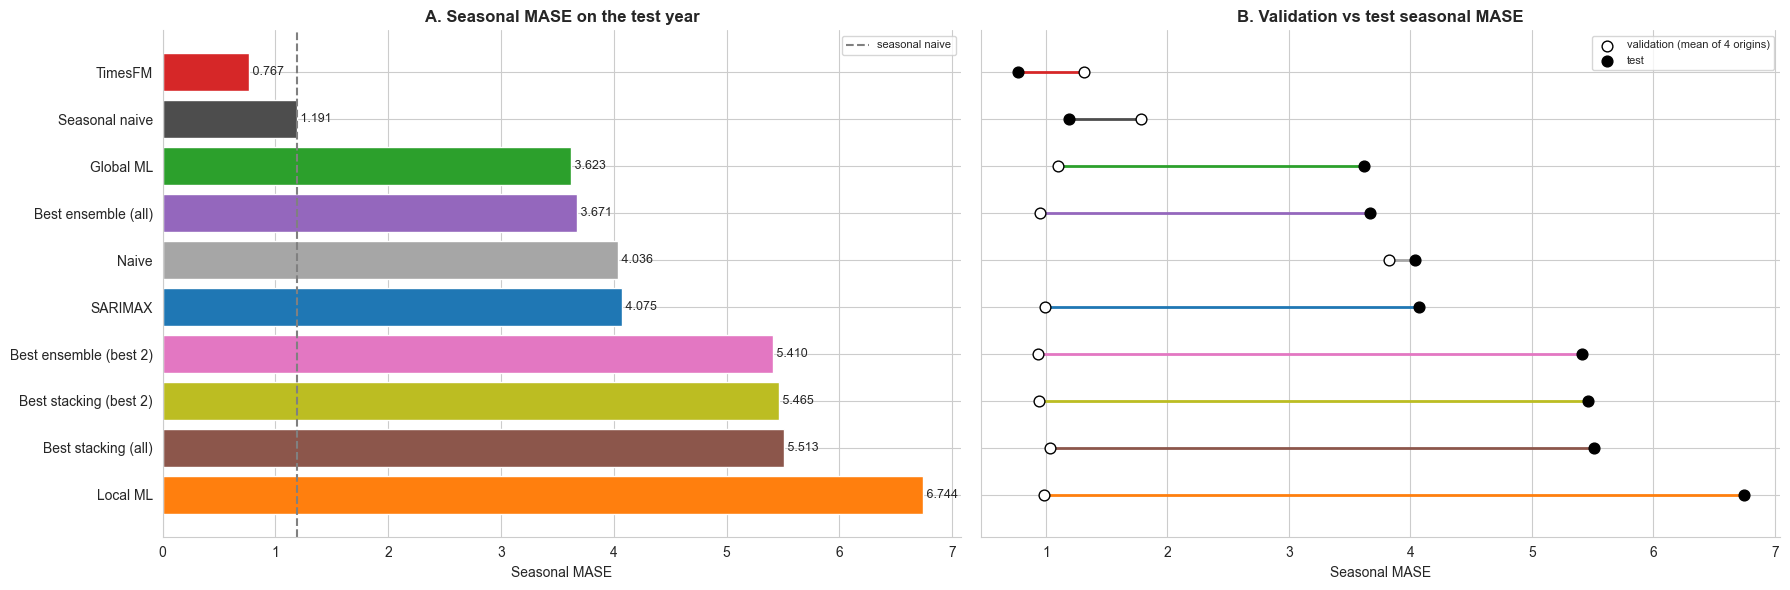

In [8]:
SNAIVE_MASE = scores.loc['Seasonal naive', 'MASE']
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
rows = ORDER[::-1]
axes[0].barh(rows, scores.loc[rows, 'MASE'], color=[APPROACH_COLORS[a] for a in rows])
for i, approach in enumerate(rows):
    axes[0].text(
        scores.loc[approach, 'MASE'],
        i,
        f' {scores.loc[approach, "MASE"]:.3f}',
        va='center',
        fontsize=9,
    )
axes[0].axvline(SNAIVE_MASE, color='grey', linestyle='--', label='seasonal naive')
axes[0].set_title('A. Seasonal MASE on the test year', fontweight='bold')
axes[0].legend(fontsize=8)

for i, approach in enumerate(rows):
    values = scores.loc[approach, ['validation MASE_mean', 'MASE']]
    axes[1].plot(values, [i, i], color=APPROACH_COLORS[approach], linewidth=2, zorder=2)
axes[1].scatter(
    scores.loc[rows, 'validation MASE_mean'],
    range(len(rows)),
    facecolor='white',
    edgecolor='black',
    s=60,
    zorder=3,
    label='validation (mean of 4 origins)',
)
axes[1].scatter(
    scores.loc[rows, 'MASE'],
    range(len(rows)),
    color='black',
    s=60,
    zorder=3,
    label='test',
)
axes[1].set_title('B. Validation vs test seasonal MASE', fontweight='bold')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel('Seasonal MASE')
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

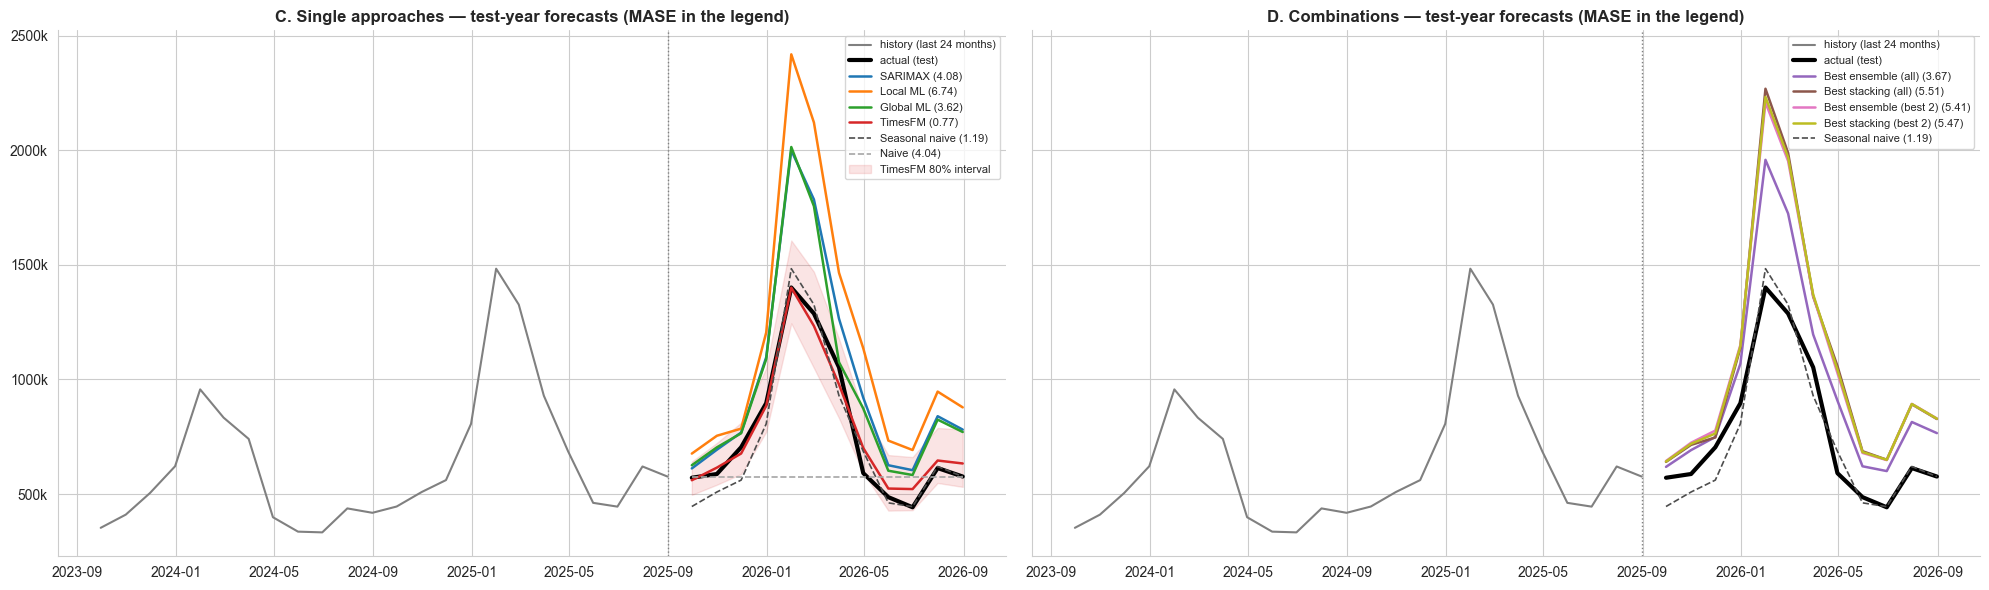

In [9]:
recent = history.iloc[-24:]
panels = [
    ('C. Single approaches', [*MEMBERS, *BASELINES]),
    (
        'D. Combinations',
        [a for a in forecasts if a.startswith('Best')] + ['Seasonal naive'],
    ),
]
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
for ax, (title, shown) in zip(axes, panels):
    ax.plot(
        recent.index,
        recent,
        color='grey',
        linewidth=1.5,
        label='history (last 24 months)',
    )
    ax.plot(
        test_actual.index,
        test_actual,
        color='black',
        linewidth=3,
        label='actual (test)',
    )
    for approach in shown:
        is_baseline = approach in BASELINES
        ax.plot(
            forecasts.index,
            forecasts[approach],
            color=APPROACH_COLORS[approach],
            linestyle='--' if is_baseline else '-',
            linewidth=1.2 if is_baseline else 1.8,
            label=f'{approach} ({scores.loc[approach, "MASE"]:.2f})',
        )
    if 'TimesFM' in shown:
        ax.fill_between(
            forecasts.index,
            timesfm_low,
            timesfm_high,
            color=APPROACH_COLORS['TimesFM'],
            alpha=0.12,
            label='TimesFM 80% interval',
        )
    ax.axvline(TEST_ORIGIN, color='grey', linestyle=':', linewidth=1)
    ax.set_title(
        f'{title} — test-year forecasts (MASE in the legend)', fontweight='bold'
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

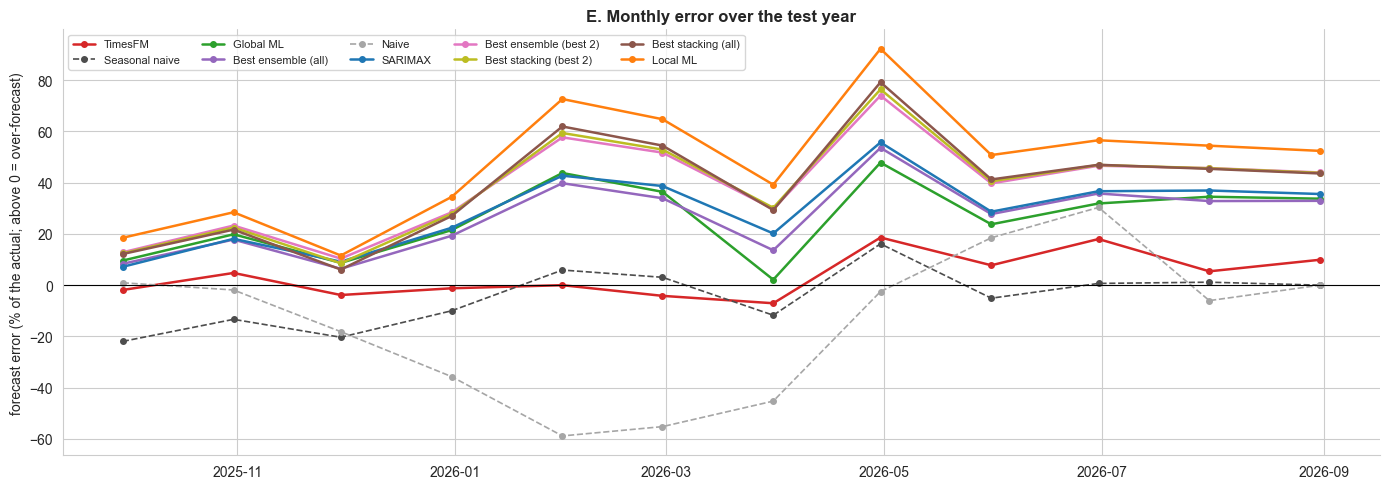

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
for approach in ORDER:
    is_baseline = approach in BASELINES
    ax.plot(
        forecasts.index,
        (forecasts[approach] - test_actual) / test_actual * 100,
        color=APPROACH_COLORS[approach],
        linestyle='--' if is_baseline else '-',
        marker='o',
        markersize=4,
        linewidth=1.2 if is_baseline else 1.8,
        label=approach,
    )
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('forecast error (% of the actual; above 0 = over-forecast)')
ax.set_title('E. Monthly error over the test year', fontweight='bold')
ax.legend(fontsize=8, ncol=5)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 7. Did the Validation Ranking Hold?

The approaches were ranked on the four validation origins; the test year checks that ranking on
data no choice has seen. The slope chart links each approach's validation score (the mean over
the four origins) to its test score. The Spearman correlation between the two rankings is
computed over the eight models (the baselines are left out).

The **growth of the test year** over the last validation year places it in one of notebook 11's
regimes (flat ≤ 5%, rapid ≥ 30%, normal growth in between). Notebook 11 showed how each approach
behaved in each regime on validation.

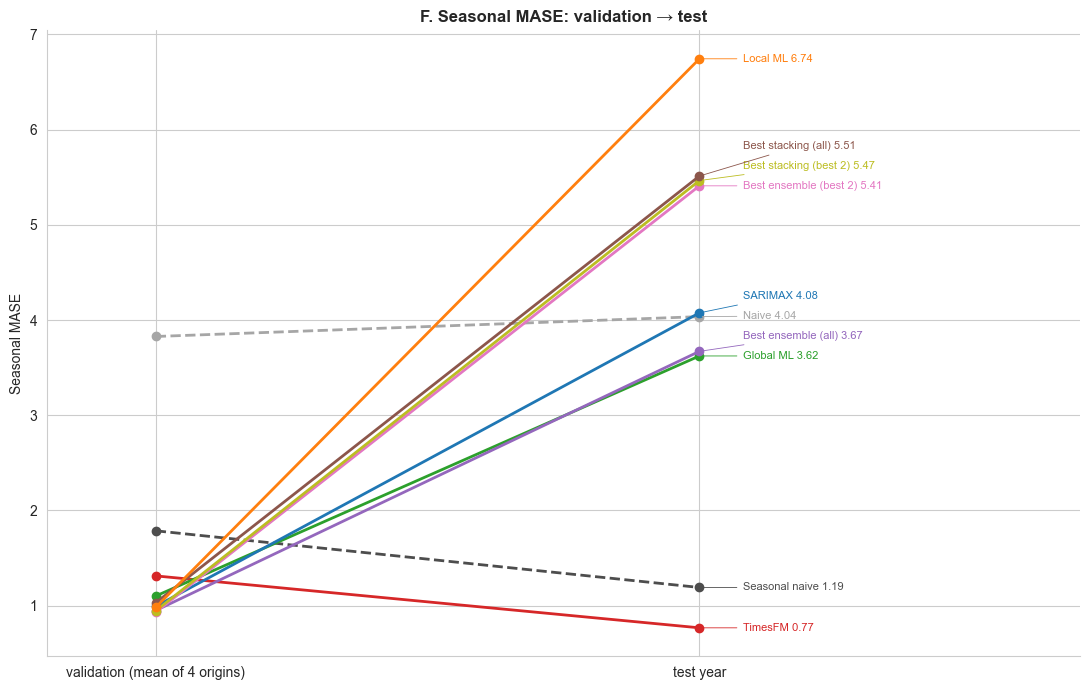

Spearman rank correlation (8 models): -0.48
Growth of the test year over the last validation year: +4.1% (flat)


,validation rank,test rank
TimesFM,8,1
Global ML,7,2
Best ensemble (all),3,3
SARIMAX,5,4
Best ensemble (best 2),1,5
Best stacking (best 2),2,6
Best stacking (all),6,7
Local ML,4,8


In [11]:
def spread_labels(values, min_gap):
    """Label positions at least `min_gap` apart, in the order of the values."""
    positions, last = {}, -np.inf
    for key, value in sorted(values.items(), key=lambda item: item[1]):
        last = max(value, last + min_gap)
        positions[key] = last
    return positions


PHASES = ['validation MASE_mean', 'MASE']
fig, ax = plt.subplots(figsize=(11, 7))
values_range = scores[PHASES].to_numpy().max() - scores[PHASES].to_numpy().min()
label_y = spread_labels(scores['MASE'].to_dict(), min_gap=0.035 * values_range)
for approach in ORDER:
    values = scores.loc[approach, PHASES]
    ax.plot(
        [0, 1],
        values,
        marker='o',
        color=APPROACH_COLORS[approach],
        linestyle='--' if approach in BASELINES else '-',
        linewidth=2,
    )
    ax.annotate(
        f'{approach} {values.iloc[1]:.2f}',
        xy=(1, values.iloc[1]),
        xytext=(1.08, label_y[approach]),
        va='center',
        fontsize=8,
        color=APPROACH_COLORS[approach],
        arrowprops={'arrowstyle': '-', 'color': APPROACH_COLORS[approach], 'lw': 0.6},
    )
ax.set_xticks([0, 1], ['validation (mean of 4 origins)', 'test year'])
ax.set_xlim(-0.2, 1.7)
ax.set_ylabel('Seasonal MASE')
ax.set_title('F. Seasonal MASE: validation → test', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

rank_correlation = spearmanr(
    scores.loc[models, 'validation MASE_mean'], scores.loc[models, 'MASE']
).statistic
test_growth = test_actual.sum() / history.iloc[-SEASONAL_PERIOD:].sum() - 1
test_regime = (
    'flat'
    if abs(test_growth) <= FLAT_GROWTH
    else 'rapid growth'
    if test_growth >= RAPID_GROWTH
    else 'normal growth'
)
ranks = pd.DataFrame({
    'validation rank': scores.loc[models, 'validation MASE_mean'].rank().astype(int),
    'test rank': scores.loc[models, 'MASE'].rank().astype(int),
}).sort_values('test rank')
print(f'Spearman rank correlation (8 models): {rank_correlation:.2f}')
print(
    f'Growth of the test year over the last validation year: {test_growth:+.1%} '
    f'({test_regime})'
)
ranks

## 8. Log the Test Results to MLflow

One run per approach in the experiment **Brazil Tourism Forecasting Final**. Each run holds the
configuration (and, for a combination, its members and weights) as parameters, the test metrics
and the validation MASE_mean as metrics, and the test forecasts as the artifact
`test_forecasts.csv` (tag `role = test_forecasts`). The runs have `eval_split = test`, so the
validation queries of notebooks 9–12 never pick them up. Every execution adds a new set of runs;
set `LOG_TO_MLFLOW = False` to re-run the notebook without logging.

In [12]:
LOG_TO_MLFLOW = True
FINAL_EXPERIMENT = 'Brazil Tourism Forecasting Final'


def finite(value):
    return isinstance(value, (int, float, np.number)) and np.isfinite(value)


if LOG_TO_MLFLOW:
    mlflow.set_experiment(FINAL_EXPERIMENT)
    weights_by_approach = pd.DataFrame(weight_rows).set_index('approach')
    for approach in ORDER:
        params = {
            'eval_split': 'test',
            'refit_end': f'{TEST_ORIGIN:%Y-%m}',
            'test_window': f'{FORECAST_DATES[0]:%Y-%m} to {FORECAST_DATES[-1]:%Y-%m}',
            'forecasts_fingerprint': FROZEN,
        }
        if approach in members:
            params['configuration'] = members[approach]['configuration'][:500]
        elif approach in combinations:
            entry = combinations[approach]
            params |= {
                'configuration': entry['configuration'],
                'members': ', '.join(entry['pool']),
                'weights': json.dumps(
                    weights_by_approach
                    .loc[approach, entry['pool']]
                    .astype(float)
                    .round(4)
                    .to_dict()
                ),
            }
        else:
            params['configuration'] = 'baseline'
        output = pd.DataFrame({
            'date': FORECAST_DATES,
            'actual': test_actual.to_numpy(),
            'forecast': forecasts[approach].to_numpy(),
        })
        with mlflow.start_run(run_name=f'TEST | {approach}'):
            mlflow.set_tags({'role': 'test_forecasts', 'approach': approach})
            mlflow.log_params(params)
            mlflow.log_metrics({
                key.replace(' ', '_'): float(value)
                for key, value in scores.loc[approach].items()
                if finite(value)
            })
            mlflow.log_text(output.to_csv(index=False), 'test_forecasts.csv')
    print(f'Logged {len(ORDER)} runs to "{FINAL_EXPERIMENT}"')

Logged 10 runs to "Brazil Tourism Forecasting Final"


## Final Summary

In [13]:
assert fingerprint() == FROZEN, 'a forecast changed after the test set was read'

best = ORDER[0]
beat_snaive = [a for a in models if scores.loc[a, 'MASE'] < SNAIVE_MASE]
validation_best = scores.loc[models, 'validation MASE_mean'].idxmin()
best_single = min(MEMBERS, key=lambda a: scores.loc[a, 'MASE'])
combined_better = [
    a for a in combinations if scores.loc[a, 'MASE'] < scores.loc[best_single, 'MASE']
]
bias = scores.loc[best, 'Forecast Bias']
display(
    Markdown(f"""
**Test year ({FORECAST_DATES[0]:%b %Y} – {FORECAST_DATES[-1]:%b %Y}).** The best
approach is **{best}** (seasonal MASE {scores.loc[best, 'MASE']:.3f}, MAPE
{scores.loc[best, 'MAPE']:.1f}%, RelMAE {scores.loc[best, 'RelMAE']:.2f}); the
seasonal naive scores {SNAIVE_MASE:.3f}. {len(beat_snaive)} of the {len(models)}
models beat the seasonal naive. The best model on validation,
**{validation_best}**, scores {scores.loc[validation_best, 'MASE']:.3f} on the test
year (rank {int(ranks.loc[validation_best, 'test rank'])} of {len(models)}), and the
Spearman correlation between the validation and test rankings is
{rank_correlation:.2f}.

The best single approach on the test year is **{best_single}**;
{len(combined_better)} of the {len(combinations)} combinations beat it
({', '.join(combined_better) or 'none'}). The best approach
{'under' if bias > 0 else 'over'}-forecast the year by {abs(bias):.1f}%. Arrivals
grew {test_growth:+.1%} over the last validation year, a **{test_regime}** year in
notebook 11's terms.
""")
)


**Test year (Sep 2025 – Aug 2026).** The best
approach is **TimesFM** (seasonal MASE 0.767, MAPE
6.9%, RelMAE 0.64); the
seasonal naive scores 1.191. 1 of the 8
models beat the seasonal naive. The best model on validation,
**Best ensemble (best 2)**, scores 5.410 on the test
year (rank 5 of 8), and the
Spearman correlation between the validation and test rankings is
-0.48.

The best single approach on the test year is **TimesFM**;
0 of the 4 combinations beat it
(none). The best approach
over-forecast the year by 1.8%. Arrivals
grew +4.1% over the last validation year, a **flat** year in
notebook 11's terms.


### Caveats

- **One year.** The test set is a single 12-month window, so every score above is one draw. A
  ranking between approaches separated by a few hundredths of MASE is not established by it; the
  four validation origins (notebooks 5–11) remain the evidence on stability, and this year is the
  unbiased check of the choices made on them.
- **Selection is closed.** Looking at these results does not reopen the selection: re-choosing a
  configuration or a combination because it scored better here would turn the test year into a
  fifth validation origin and remove the only unbiased score of the project.
- **Combination weights** were learned from members trained up to earlier origins, with less data
  than the retrained members; with 48 validation months, the stacking weights carry a large
  uncertainty (notebook 10's leave-one-origin-out tables).
- **TimesFM pretraining.** TimesFM 3.0 was released after the start of the test year and was
  pretrained on a large public corpus. That corpus may include tourism statistics that overlap
  this series, even part of the test year, which this project cannot rule out. Its test score is
  therefore an upper bound on how well a model would do on truly unseen data.